In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as cp
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from FallbackGen import FallbackGen
from TDECalculator import TDECalculator

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [2]:
MBH = 1e6
Rp = 18
a = 0.001
N = 1000
E = 1.0
Q = 0.0
orbit="rel"

mass1 = TDECalculator('MAMS1Msun', orbit, MBH, Rp, a)

rtde = mass1.R_TDE
Lz = mass1.mom_kerr_analytic(Rp, a)

In [3]:
sample1 = mass1.rel_whole_star_sample()

In [4]:
radii = sample1['rr']

radii = np.where(
    radii <= 0.5,
    rtde - radii * mass1.Rstar,
    rtde + radii * mass1.Rstar
)

In [5]:
i = int(np.random.uniform(0, 1132))
j = int(np.random.uniform(0, 90000))
dE = sample1['dEnergy_random'] * mass1.DeltaE 
dLz = mass1.dLz_random
dQ = mass1.dQ_random
mass_ratio = mass1.mass_ratio

In [6]:
E = 1.0
Lz = mass1.mom_kerr_analytic(Rp, a)
Q = 0

In [7]:
dT = FallbackGen(mass_ratio, a, radii, Rp, E, Lz, Q, dE, dLz, dQ, N)

Computing radial periods for 101,880,000 particles ...
  E  range: [0.998899, 1.001101]
  Q  range: [-2.117e-01, 2.116e-01]
  chunk_size = 1,500,000
  Finding roots (batched eigensolver) ...
  Bound: 50,822,665 / 101,880,000
  Valid roots: 50,822,665
  Valid Lambda_r: 50,822,665
  Quadrature: 34 chunks ...
    chunk 34/34  (100%)
  Successful T_r: 50,822,665 / 101,880,000


In [8]:
n_ex = TDECalculator('MAMS1Msun', Rp=Rp, a=0.0)

In [9]:
whole_star_sample4 = n_ex.whole_star_sample(N_Omega=300**2)

In [31]:
def make_plot_dicts(whole_star_sample, dT, delta):
    dE_rand = whole_star_sample['dEnergy_random']
    dT_rand = dT / delta
    dMass   = whole_star_sample['dMass']

    bins_E = np.linspace(-2, 2, 200)
    bins_T = np.logspace(0, 6, 200)

    hist_E, edges_E = np.histogram(dE_rand.flatten(), bins=bins_E,
                                   weights=dMass.flatten(), density=True)
    hist_T, edges_T = np.histogram(dT_rand.flatten(), bins=bins_T,
                                   weights=dMass.flatten(), density=True)

    return {"x": 0.5*(edges_E[:-1]+edges_E[1:]), "y": hist_E}, \
           {"x": 0.5*(edges_T[:-1]+edges_T[1:]), "y": hist_T}

In [32]:
def energy_plots(whole_star_sample): 
    # unpack
    dE_rand   = whole_star_sample['dEnergy_random']      # shape (nr-1, N_Omega)
    dE_unp    = whole_star_sample['dEnergy_unperturbed']
    dT_rand   = whole_star_sample['dT_random']
    dT_unp    = whole_star_sample['dT_unperturbed']
    dMass     = whole_star_sample['dMass']               # same shape

    # set up figure
    # fig, (axE, axT) = plt.subplots(1, 2, figsize=(12,5))

    # histograms in E
    bins_E = np.linspace(-2, 2, 200)
    # axE.hist(dE_rand.flatten(),
    #         weights=dMass.flatten(),
    #         bins=bins_E,
    #         density=True,
    #         alpha=0.5)
    # axE.set_yscale('log')
    # axE.set_xlabel(r'$ E / \Delta E$')
    # axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
    # axE.set_xlim(-1,1)
    # axE.set_ylim(1e-5)

    # histograms in T
    bins_T = np.logspace(0, 6, 200)
    # axT.hist(dT_rand.flatten(),
    #         weights=dMass.flatten(),
    #         bins=bins_T,
    #         density=True,
    #         alpha=0.5)
    # # overplot T^{-5/3} reference
    # axT.plot(bins_T, 10*bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
    # axT.set_xscale('log')
    # axT.set_yscale('log')
    # axT.set_xlabel(r'$T / \Delta T$')
    # axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
    # axT.set_xlim(1,2000)
    # axT.set_ylim(2e-5,0.1)

    # plt.tight_layout()
    # plt.show()
    
    hist_vals_E, bin_edges_E = np.histogram(
        dE_rand.flatten(),
        bins=bins_E,
        weights=dMass.flatten(),
        density=True
        )
    
    hist_vals_T, bin_edges_T = np.histogram(
        dT_rand.flatten(),
        bins=bins_T,
        weights=dMass.flatten(),
        density=True
        )
    
    bin_centers_E = 0.5 * (bin_edges_E[:-1] + bin_edges_E[1:]) # Save the curve for later
    bin_centers_T = 0.5 * (bin_edges_T[:-1] + bin_edges_T[1:]) # Save the curve for later
    
    curve_E = {
        "x": bin_centers_E,
        "y": hist_vals_E
        }
    
    curve_T = {
        "x": bin_centers_T,
        "y": hist_vals_T
        }
    
    return curve_E, curve_T

In [33]:
n_E, n_T = energy_plots(whole_star_sample4)

In [34]:
DeltaE = n_ex.Rstar / n_ex.Rp**2
DeltaT = 1 / DeltaE**1.5

In [35]:
rel_E, rel_T = make_plot_dicts(sample1, dT.dTs, DeltaT)

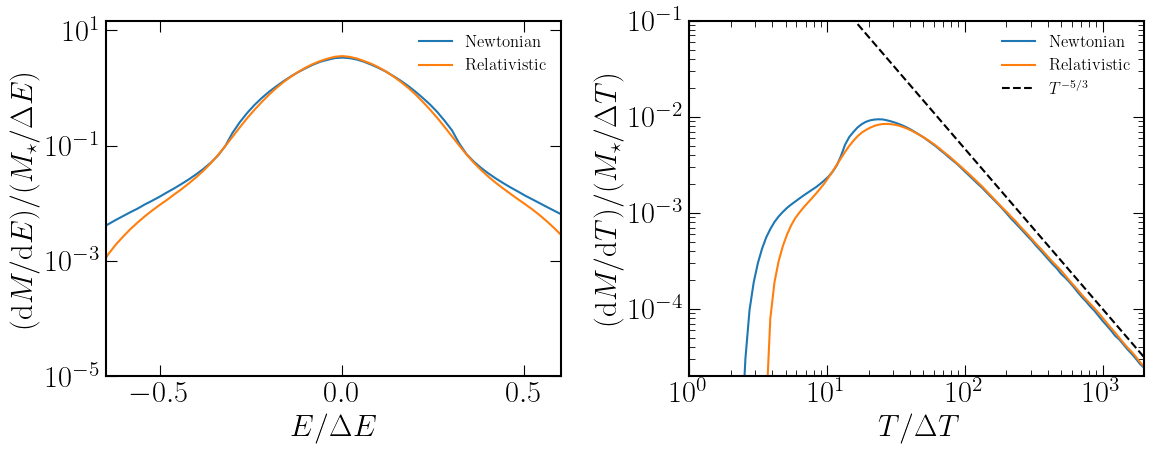

In [36]:
# Build dicts

# Plot
fig, (axE, axT) = plt.subplots(1, 2, figsize=(12, 5))

# Energy
axE.plot(n_E["x"],   n_E["y"],   label="Newtonian")
axE.plot(rel_E["x"], rel_E["y"], label="Relativistic")
axE.set_yscale('log')
axE.set_xlabel(r'$E / \Delta E$')
axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
axE.set_xlim(-0.65, 0.6)
axE.set_ylim(1e-5)
axE.legend(fontsize=12)

# Period
axT.plot(n_T["x"],   n_T["y"],   label="Newtonian")
axT.plot(rel_T["x"], rel_T["y"], label="Relativistic")
bins_T = np.logspace(0, 6, 200)
axT.plot(bins_T, 10 * bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
axT.set_xscale('log')
axT.set_yscale('log')
axT.set_xlabel(r'$T / \Delta T$')
axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
axT.set_xlim(1,2000)
axT.set_ylim(2e-5,0.1)
axT.legend(fontsize=12)

plt.tight_layout()
plt.show()